In [1]:
import numpy as np 
import matplotlib
import matplotlib.pyplot as plt
import scipy.stats as stats
import math
from matplotlib.pyplot import figure
import pandas as pd
from scipy import integrate
import numpy.matlib
from scipy.optimize import curve_fit
from scipy.stats import norm
import statistics
  
from operator import add
matplotlib.rcParams['axes.labelsize'] = 20
matplotlib.rcParams['axes.titlesize'] = 24
matplotlib.rcParams['xtick.labelsize'] = 15
matplotlib.rcParams['xtick.major.size'] = 10
matplotlib.rcParams['xtick.minor.size'] = 5
matplotlib.rcParams['ytick.labelsize'] = 15
matplotlib.rcParams['ytick.major.size'] = 10
matplotlib.rcParams['ytick.minor.size'] = 5


## OD to concentration calibration 
## Note that experimental OD values and corresponding error data that will be used in this notebook comes from "MOI_data.xlsx" in Github Folder "Experimental Data"

9017858.54670966


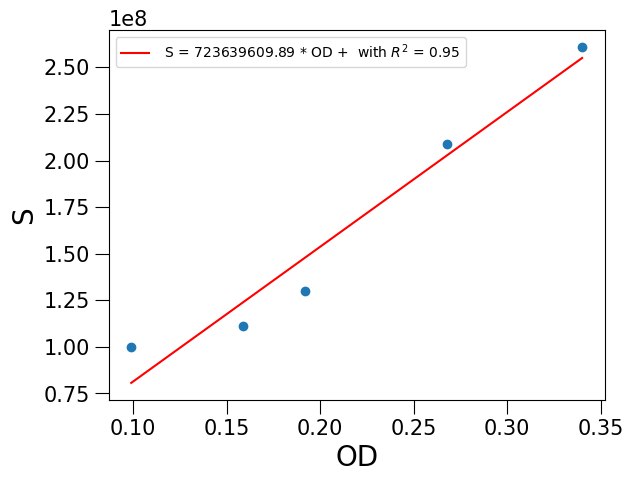

In [2]:
def func(x, a,b):
    return a * x + b
OD = np.array( [0.099,0.159,0.192,0.268,0.34])
S = np.array([9.97E+07,1.11E+08,1.30E+08,2.09E+08,2.61E+08])
plt.scatter(OD,S)
plt.xlabel('OD')
plt.ylabel('S')
x=OD
y=S
popt, pcov = curve_fit(func, x, y, p0 = [(10**8,10**8)])

residuals = y- func(x, *popt)
ss_res = np.sum(residuals**2)
ss_tot = np.sum((y-np.mean(y))**2)
r_squared = 1 - (ss_res / ss_tot)
                 
plt.plot(x, func(x, *popt), 'r-', label= " S = " +str(round(popt[0],2)) + ' * OD + '+  r' with $R^{2}$ = ' + str(round(r_squared,2)) )
plt.legend()
xx=np.array(x[1:len(x)-1]) # your list of values goes in there
S0 = popt[1] #Initial concentration at OD = 0
print(S0)

## Applying calibration conversion function to get infection curves in terms of concentration (Fig 3c)

(0.0, 250.0)

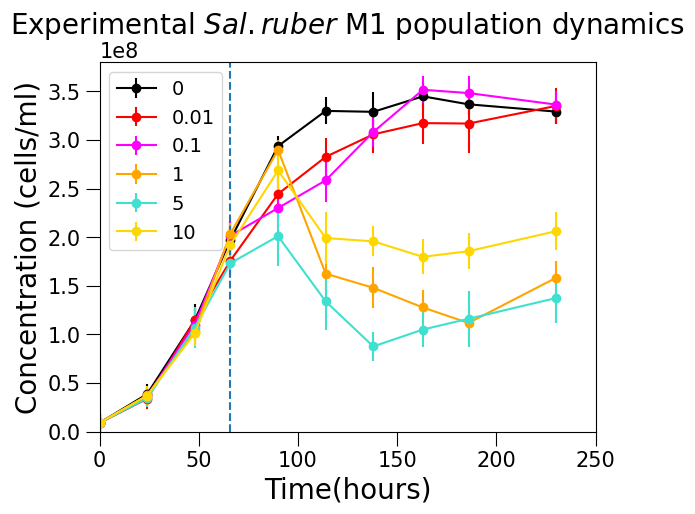

In [3]:
colors = ['red','fuchsia','orange','turquoise','gold']

OD_data =[ 0,0.041,0.145666667,0.260333333,0.393333333,0.443333333,0.442,0.464,0.452666667,0.442333333]
error_0 = [0,0.001732051,0.01134803,0.014518188,0.001763834,0.006565905,0.015011107,0.007571878,0.002403701,0.004484541]

OD_data_001 =[0,0.034333333,0.145666667,0.230666667,0.325333333,0.378,0.41,0.426,0.425333333,0.450333333]
error_001 = [0,0.002333333,0.006741249,0.007535103,0.012719189,0.014,0.013856406,0.017009801,0.02944675,0.01299145]

OD_data_01 = [0,0.038,0.139666667,0.266,0.305333333,0.344666667,0.413333333,0.473333333,0.468666667,0.452333333]
error_01 =[0,0.002081666,0.01065103,0.008962886,0.005333333,0.018487233,0.008353309,0.006666667,0.011623731,0.006385748]

OD_data_1 = [0,0.039,0.131,0.269,0.388,0.212,0.192,0.164,0.142,0.206]
error_1 = [0,0.001,0.005897269,0.002962731,0.001763834,0.011718931,0.016384274,0.012346839,0.007571878,0.011170397]


OD_data_5= [0,0.035,0.135333333,0.227,0.265333333,0.172666667,0.108666667,0.132666667,0.148,0.177333333]
error_5 = [0,0.00057735,0.016505891,0.008717798,0.029310597,0.028339215,0.00851143,0.011794537,0.027153882,0.022430138]

OD_data_10 =[0,0.038666667,0.127333333,0.253333333,0.358666667,0.262666667,0.258,0.236,0.244,0.272333333]
error_10 = [0,0.000881917,0.004977728,0.014903393,0.023132469,0.024828299,0.0090185,0.012489996,0.012858201,0.014621141]


t = [0,24,48,66,90,114,138,163,186,230]
x1=t
y1=OD_data
MOI_vals_labels = [0,0.01,0.1,1,5,10]

OD_data_err = np.array(error_0)
OD_data_err_001 = np.array(error_001)
OD_data_err_01 = np.array(error_01)
OD_data_err_1 = np.array(error_1)
OD_data_err_5 = np.array(error_5)
OD_data_err_10 = np.array(error_10)

S_control_error = func(OD_data_err, *popt)
S_error_001 = func(OD_data_err_001, *popt)
S_error_01 = func(OD_data_err_01, *popt)
S_error_1 = func(OD_data_err_1, *popt)
S_error_5 = func(OD_data_err_5, *popt)
S_error_10 = func(OD_data_err_10, *popt)

OD_data_arr = np.array(OD_data)
S_control_data = func(OD_data_arr, *popt)
plt.errorbar(x1,S_control_data,S_control_error,marker='o', color = 'black')

OD_data_001 = np.array(OD_data_001)
data_001=func(OD_data_001, *popt)
plt.errorbar(x1,data_001,S_error_001,marker='o', color = colors[0])

OD_data_01 = np.array(OD_data_01)
data_01=func(OD_data_01, *popt)
plt.errorbar(x1,data_01,S_error_01,marker='o', color = colors[1])


OD_data_1 = np.array(OD_data_1)
data_1=func(OD_data_1, *popt)
plt.errorbar(x1,data_1,S_error_1,marker='o', color = colors[2])


OD_data_5 = np.array(OD_data_5)
data_5=func(OD_data_5, *popt)
plt.errorbar(x1,data_5,S_error_5,marker='o',color = colors[3])



OD_data_10 = np.array(OD_data_10)
data_10=func(OD_data_10, *popt)
plt.errorbar(x1,data_10,S_error_10,marker='o', color = colors[4])



plt.title(r'Experimental $\it{Sal.ruber}$ M1 population dynamics', fontsize = 20)
plt.legend(MOI_vals_labels, fontsize = 14)
plt.axvline(66, linestyle = '--')
plt.ylabel('Concentration (cells/ml)')
plt.xlabel('Time(hours)')
plt.ylim(0,3.8*10**8)
plt.xlim(0,250)
#plt.savefig("Experimental.png", bbox_inches = "tight")

## Parameters used

In [4]:
pars={}

# Graph style parameters 
colors = ['black','red','fuchsia','orange','turquoise','gold'] # 


# Fitted parameters for control growth of Sal.Ruber M1 and pseudolysogen 
mu_max_vals=[0.06,0.06,0.06,0.06,0.06,0.06]
pars['e'] = 0.75*10**-7 #conversion efficiency 
pars['mu_max'] = 0.06 #maximum growth rate of cells 
pars['R_in'] =8 #half saturation constant 
pars['R0'] = 25 #initial resource concentration
pars['alpha'] = 0 #growth advantage for pseudolysogens 

#Infection parameters 
MOI_vals= [0,0.01,0.1,1,5,10] #MOIs used in experiment (Fig 3)
pars['n'] = 8 #maximum cell MOI 
vals = np.arange(pars['n']) #all potential cell MOIs 
phi_initial = 4*10**-10 
#adsoprtion rate (allowed to vary as a function of MOI but kept constant at 4*10**-10 ml/h)   
phi_vals = [phi_initial]    
for i in (vals+1):
    phi_vals.append(phi_initial)
pars['sig']= 0.06 #viral sensity to resource levels 
pars['phi'] = phi_vals #assigning adsoprtion rate 
pars['bet'] = 10 #burst size


# Life history stage transiton parameters
phi_values = []
eta_values = []
lam_values = []
beta_values = []
pars['eta'] = 1/11 # lysis rate
pars['a'] = 1.7 #parameter that defines latent period as a function of superinfection 
lam_initial = 1/6.8  #transition from singly infected early stage pseudoysogen to fully formed pseudolysogen 
#pseudolysogen transitions from early to fully formed stage dependent for different cell MOIs (k)
for i in vals+1:
    lam_value =lam_initial/((pars['a'])**i)
    if 1/lam_value + 1/pars['eta'] < 550:
        lam_values.append(lam_value)
        threshold_lam = lam_value
    else:
        lam_values.append(threshold_lam)
        
#Setting up array of coefficients for pseudolysogen replication 
mat =  [[0]*pars['n']]*pars['n']
for i in vals:
    for j in vals:
        mat[i][j] = (1/(2+j))
pars['rep'] = np.triu(mat, k=0) #coefficients for pseudolysogenic replication (n/k+1)



#Decay rates (no decay model)
pars['dR'] = 0 # decay rates for each compartment (all 0)
pars['dS'] = 0 
pars['dE'] = 0
pars['dL'] = 0
pars['dI'] = 0
pars['dV'] = 0



#Simulation/Experimental timeframe 
virus_insert_time = 66 
t0 = 0 
tf = virus_insert_time #66 hour time insertion 
tstep = 0.1
t = np.arange(t0,tf+tstep,tstep)

## Fig S1: Defining how the latent period varies as a function of cell MOI 

Text(0.5, 1.0, 'Latent period as a function of superinfection')

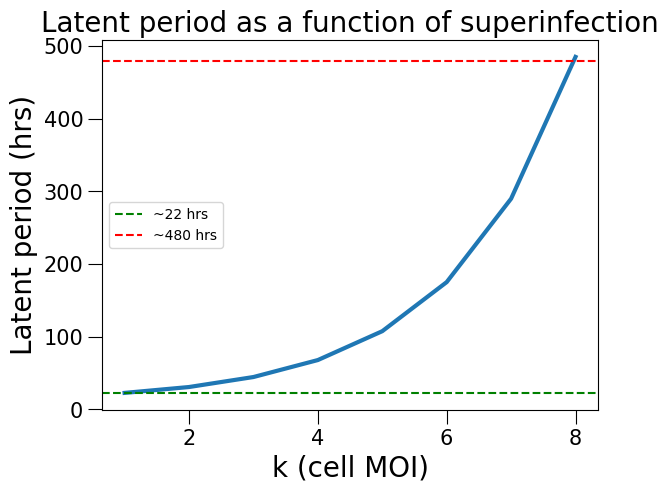

In [5]:
lat_per=[]
for i in lam_values:
    lat_per.append(1/i + 1/pars['eta'])
plt.plot(vals+1,lat_per, linewidth=3.0)
plt.axhline(22, linestyle = '--', color = 'green', label = '~22 hrs')
plt.axhline(480, linestyle = '--', color = 'red', label = '~480 hrs')
plt.ylabel('Latent period (hrs)')
plt.xlabel('k (cell MOI)')
plt.legend()
plt.title('Latent period as a function of superinfection', fontsize =20)
#plt.savefig('LP.pdf', bbox_inches = "tight")

## Main Model 

In [6]:
def Main_Model(y,t,pars):
    if pars['n'] == 0:
        return ('Need n>0 classes')
    if pars['n'] == 1:
        dy= np.zeros(5)
        R = y[0]
        S = y[1]
        E = y[2]
        I = y[3]
        V = y[4]
        
        psy_R = pars['mu_max'] * (R/(R+pars['R_in']))
        gamma = (R/(R+pars['sig']*pars['R_in']))/(pars['R0']/(pars['R0']+pars['sig']*pars['R_in']))
        
        #gamma =1
        
        dy[0] =  - pars['e']* psy_R*(S+E) #R
        dy[1] = psy_R * S  - pars['phi'][0] * S* V +psy_R*E + psy_R*I #S
        dy[2] = pars['phi'][0] * S* V  - pars['lam'][0]*E  #E
        dy[3] = pars['lam'][0]*E - gamma*(pars['eta'] * I) #I
        dy[4] = gamma*(pars['bet']*pars['eta'] * I) - (pars['phi'][0]*S + pars['phi'][0]*E)* V #V
        
        return dy  
    else:
        dy = np.zeros(2*pars['n']+3)
        R = y[0]
        S = y[1]
        Pe_1 = y[2]
        Pe_s = y[3:(pars['n']+1)]
        Pe_k = y[pars['n'] + 1]
        Pf_1 = y[pars['n']+2]
        Pf_s = y[(pars['n']+3):(2*pars['n']+1)]
        Pf_k = y[2*pars['n'] + 1]
        V = y[2*pars['n'] + 2]

        Pe_prev = np.concatenate((Pe_1 ,  Pe_s[0:-1]), axis = None)
        Pe_total = np.concatenate((Pe_1 ,  Pe_s, Pe_k), axis = None)
        
        Pe_sum = np.sum(Pe_total)
        
        Pf_prev = np.concatenate((Pf_1 ,  Pf_s[0:-1]), axis = None)
        Pf_total = np.concatenate((Pf_1 ,  Pf_s, Pf_k), axis = None)
        
        Pf_sum = np.sum(Pf_total)

 
        psy_R = pars['mu_max'] * (R/(R+pars['R_in']))
        gamma = (R/(R+pars['sig']*pars['R_in']))/(pars['R0']/(pars['R0']+pars['sig']*pars['R_in']))

        Pe_topmid = np.concatenate((Pe_1 ,  Pe_s), axis = None)
        Pf_topmid = np.concatenate((Pf_1 ,  Pf_s), axis = None)
  
        
        
        lam_sum = np.sum(pars['lam'])


        dy[0] =  - pars['e']* psy_R*(S +(1/(1-pars['alpha'])) * ((np.sum(Pe_total))+np.sum(Pf_total))) - pars['dR'] * R #R
        #print(pars['rep'][1:-1])
        #print(Pe_total)
     
        dy[1] = psy_R * S  - pars['phi'][0]  * S* V   + 2* psy_R * np.sum(1/(1-pars['alpha']) * (pars['rep'][0]*Pe_total)) + 2* psy_R * np.sum(1/(1-pars['alpha']) * (pars['rep'][0]*Pf_total)) - pars['dS']*S # S

        dy[2] = pars['phi'][0] * S * V - pars['phi'][1] * Pe_1 * V  -  (pars['lam'][0] * Pe_1) - (psy_R)*Pe_1 + 1/(1-pars['alpha'])*2*psy_R*np.sum(pars['rep'][0]*(Pe_total), axis = 0)-  pars['dE'] * Pe_1  #Pe_1

        dy[3:(pars['n']+1)]  = pars['phi'][1:-2] * Pe_prev * V - pars['phi'][2:-1] * Pe_s * V -  (pars['lam'][1:-1] * Pe_s) -(psy_R)*Pe_s + 2*psy_R * np.sum(pars['rep'][1:-1]*Pe_total, axis = 1)/(1-pars['alpha'])- pars['dE'] * Pe_s  # Pe_s
        
        dy[pars['n']+1]  = pars['phi'][-1] * Pe_topmid[-1]*V -  (pars['lam'][-1] * Pe_k) -  (psy_R)*Pe_k +  2*psy_R*np.sum(pars['rep'][-1]*(Pe_k), axis = 0)/(1-pars['alpha'])-  pars['dE'] * Pe_k  #Pe_K

        dy[pars['n']+2] = pars['lam'][0]*Pe_1 - gamma * (pars['eta'] * (Pf_1)) -  (psy_R)*Pf_1 + 1/(1-pars['alpha'])*2*psy_R*np.sum(pars['rep'][0]*(Pf_total), axis = 0) #Pf_1
        
        dy[(pars['n']+3):(2*pars['n']+1)] = (pars['lam'][1:-1] * Pe_s) - gamma * (pars['eta'] * (Pf_s)) - (psy_R)*Pf_s + 2*psy_R * np.sum(pars['rep'][1:-1]*Pf_total, axis = 1)/(1-pars['alpha']) #Pf_s
        
        dy[2*pars['n'] + 1]= pars['lam'][-1]*Pe_k - gamma * (pars['eta'] * (Pf_k)) -  (psy_R)*Pf_k +  2*psy_R*np.sum(pars['rep'][-1]*(Pf_k), axis = 0)/(1-pars['alpha']) #Pf_k
        
        dy[2*pars['n']+2] = pars['bet']*gamma * (pars['eta'] * (Pf_sum))- V*(pars['phi'][0] * S + np.sum(pars['phi'][2:-1] * Pe_prev) + pars['phi'][-1] * Pe_topmid[-1]) - pars['dV'] * V #V
        
 
        
        #print(np.sum(pars['bet']*I*pars['eta']))
        #print(psy_R)
        return dy  

## Parameters used

In [7]:
pars={}

mu_max_vals=[0.06,0.06,0.06,0.06,0.06,0.06]

MOI_vals= [10,5,1,0.1,0.01,0]

colors = ['black','red','fuchsia','orange','turquoise','gold']

mu_max_vals.reverse()
MOI_vals.reverse()
virus_insert_time = 67
pars['n'] = 8
MOI = np.arange(pars['n']) +1
vals = np.arange(pars['n']) 
mat =  [[0]*pars['n']]*pars['n']

for i in vals:
    for j in vals:
        mat[i][j] = (1/(2+j))
pars['rep'] = np.triu(mat, k=0) #coefficients for pseudolysogenic replication (n/k+1)




pars['e'] = 0.75*10**-7 #conversion efficiency 
pars['mu_max'] = 0.06 #maximum growth rate of cells 
pars['R_in'] =8 #half saturation constant 
pars['R0'] = 25 #initial resource concentration


MOI = np.arange(pars['n']) +1 


phi_values = []
eta_values = []
lam_values = []
beta_values = []


lam_initial = 1/6.8
pars['eta'] = 1/11 #transition rate from singly infected early pseudolysogen to singly infected fully formed pseudolysogen 
pars['a'] = 1.7 #parameter that defines latent period as a function of superinfection 

#MOI = np.linspace(0,pars['n'],1000)

MOI = np.arange(pars['n']) +1
#MOI = np.linspace(0,pars['n'],1000)
for i in MOI:
    lam_value =lam_initial/((pars['a'])**i)
    if 1/lam_value + 1/pars['eta'] < 550:
        lam_values.append(lam_value)
        threshold_lam = lam_value
    else:
        lam_values.append(threshold_lam)



phi_initial = 4*10**-10 #adsoprtion rate         
phi_vals = [phi_initial]
for i in (vals+1):
    phi_vals.append(phi_initial)

phi_vals


#MOI = np.linspace(0,pars['n'],1000)


pars['sig']= 0.06 #viral sensity to resource levels 
pars['lam'] = lam_values #transition rates from early pseudolysogens to fully formed pseudolysogens 

pars['dR'] = 0 # decay rates for each compartment (all 0)
pars['dS'] = 0 
pars['dE'] = 0
pars['dL'] = 0
pars['dI'] = 0
pars['dV'] = 0
pars['bet'] = 10 #burst size
pars['phi'] = phi_vals #adsoprtion rate constant at 4 * 10**-10 for all cells
pars['alpha'] =0#selective advantage for pseudolysogens in consuming resources


t0 = 0 
tf = virus_insert_time #66 hour time insertion 
tstep = 0.1
t = np.arange(t0,tf+tstep,tstep)


### Model results assuming same initial growth of uninfected culture 

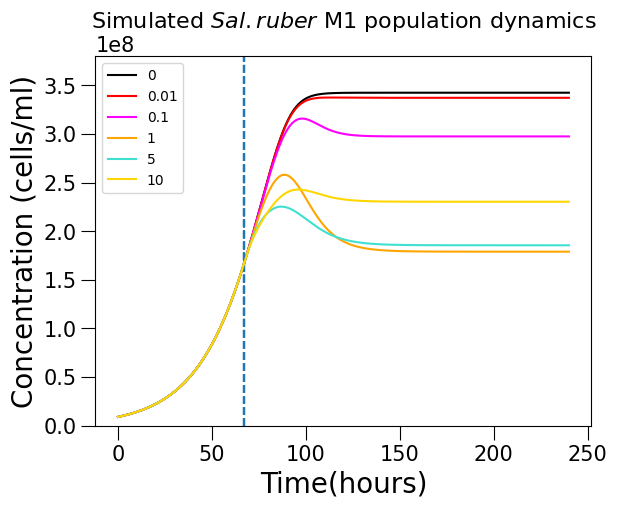

In [8]:
mu_max_vals=[0.06,0.06,0.06,0.06,0.06,0.06]

MOI_vals= [10,5,1,0.1,0.01,0]
colors = ['black','red','fuchsia','orange','turquoise','gold']
mu_max_vals.reverse()
MOI_vals.reverse()
virus_insert_time = 67
Rvals = []
Svals = []

Pf_finals = []
Pe_finals = []


Pe_dist_final=[]
for b in range(len(mu_max_vals)):
    pars['mu_max'] = mu_max_vals[b]
    t0 = 0
    tf = virus_insert_time
    tstep = 0.1
    t = np.arange(t0,tf+tstep,tstep)

    y01 = np.zeros(2*pars['n']+3)
    y01[0] = pars['R0'] #initial resource concentration 
    y01[1] = S0 #initial susceptible concentration 
    y01[-1] = 0#initial free virus concentration 
    y1 = integrate.odeint(Main_Model,y01,t,atol = 10**-8,args=(pars,))
    R_0 = y1[:,0]
    S_0 = y1[:,1]
    Pe1_0 = y1[:,2]
    Pe_mid_0 = y1[:,3:(pars['n']+1)]
    Pe_final_0 = y1[:,(pars['n']+1)]
    Pf1_0 = y1[:,pars['n']+2]
    Pf_mid_0 = y1[:,(pars['n']+3):(2*pars['n']+1)]
    Pf_final_0 = y1[:,2*pars['n'] + 1]
    V=y1[:,(2*pars['n']+2)]

    Pe_total_mid_0 = np.sum(Pe_mid_0, axis = 1)
    Pf_total_mid_0 = np.sum(Pf_mid_0, axis = 1)
    Pe_total_0 = np.sum([Pe1_0,Pe_total_mid_0,Pe_final_0], axis = 0)

    Pf_total_0 = np.sum([Pf1_0,Pf_total_mid_0,Pf_final_0], axis = 0)

    host_pop_0 = S_0 + Pe_total_0 + Pf_total_0
    plt.ylabel('Concentration (cells/ml)')
    plt.xlabel('Time(hours)')

    plt.title('S+Pe+Pf+L')
    plt.axvline(virus_insert_time, linestyle = '--')
    plt.plot(t,host_pop_0, color = colors[b])
    Rvals.append(R_0[-1])
    Svals.append(S_0[-1])

    #######
    
    t0 = virus_insert_time
    tf = 240
    tstep = 0.1
    t = np.arange(t0,tf+tstep,tstep)

    y01 = np.zeros(2*pars['n']+3)
    BULK_MOI  = MOI_vals[b]
    y01[0] = Rvals[b] #initial resource concentration 
    y01[1] = Svals[b] #initial susceptible concentration 
    y01[-1] = BULK_MOI * y01[1] #initial free virus concentration 
    #print( y01[1])
    #print(MOI_vals[i])
    y1 = integrate.odeint(Main_Model,y01,t,atol = 10**-8,args=(pars,))
    
    R3= y1[:,0]
    S3 = y1[:,1]
    Pe13 = y1[:,2]
    Pe_mid3 = y1[:,3:(pars['n']+1)]
    Pe_final3 = y1[:,(pars['n']+1)]
    Pf13 = y1[:,pars['n']+2]
    Pf_mid3 = y1[:,(pars['n']+3):(2*pars['n']+1)]
    Pf_final3 = y1[:,2*pars['n'] + 1]
    V3=y1[:,(2*pars['n']+2)]

    Pe_total_mid3 = np.sum(Pe_mid3, axis = 1)
    Pf_total_mid3 = np.sum(Pf_mid3, axis = 1)
    Pe_total3 = np.sum([Pe13,Pe_total_mid3,Pe_final3], axis = 0)

    Pf_total3 = np.sum([Pf13,Pf_total_mid3,Pf_final3], axis = 0)

    host_pop3 = S3 + Pe_total3 + Pf_total3
    
    plt.plot(t,host_pop3, color = colors[b], label = str(BULK_MOI))
    plt.ylabel('Concentration (cells/ml)')
    plt.xlabel('Time(hours)')
    plt.title(r'Simulated $\it{Sal.ruber}$ M1 population dynamics', fontsize = 16)
    Pe_dist=[]
    Pe_dist.append(Pe13[-1])
    for a in range(len(Pe_mid3[0])):
        Pe_dist.append(Pe_mid3[:,a][-1])
    Pe_dist.append(Pe_final3[-1])
    Pe_dist_final.append(Pe_dist) 
    plt.legend()
    
    Pf_finals.append(Pf_total3)
    Pe_finals.append(Pe_total3)
plt.ylim(0,3.8*10**8)
#plt.savefig('Final_result.png')
plt.show()





## Model results after calibrating for varying initial growth of uninfected culture (Fig 5a) 

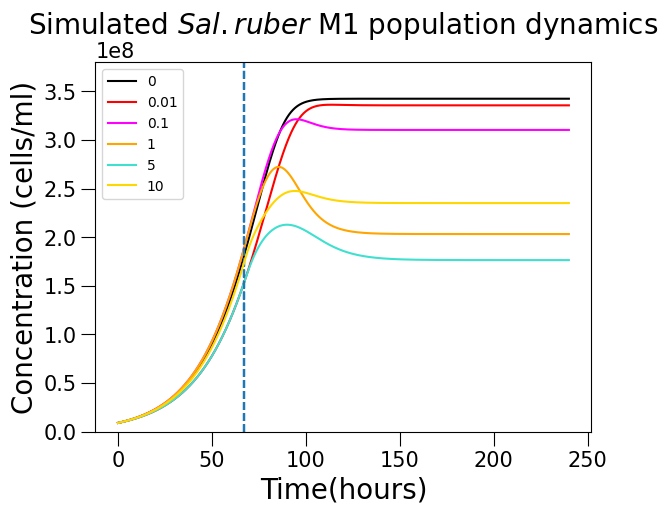

In [9]:
mu_max_vals=[0.061,0.058,0.063,0.063,0.058,0.062]

MOI_vals= [10,5,1,0.1,0.01,0]
colors = ['black','red','fuchsia','orange','turquoise','gold']
mu_max_vals.reverse()
MOI_vals.reverse()
virus_insert_time = 67
Rvals = []
Svals = []

Pf_finals = []
Pe_finals = []


Pe_dist_final=[]
Pf_dist_final = []
for b in range(len(mu_max_vals)):
    pars['mu_max'] = mu_max_vals[b]
    t0 = 0
    tf = virus_insert_time
    tstep = 0.1
    t = np.arange(t0,tf+tstep,tstep)

    y01 = np.zeros(2*pars['n']+3)
    y01[0] = pars['R0'] #initial resource concentration 
    y01[1] = S0 #initial susceptible concentration 
    y01[-1] = 0#initial free virus concentration 
    y1 = integrate.odeint(Main_Model,y01,t,atol = 10**-8,args=(pars,))
    R_0 = y1[:,0]
    S_0 = y1[:,1]
    Pe1_0 = y1[:,2]
    Pe_mid_0 = y1[:,3:(pars['n']+1)]
    Pe_final_0 = y1[:,(pars['n']+1)]
    Pf1_0 = y1[:,pars['n']+2]
    Pf_mid_0 = y1[:,(pars['n']+3):(2*pars['n']+1)]
    Pf_final_0 = y1[:,2*pars['n'] + 1]
    V=y1[:,(2*pars['n']+2)]

    Pe_total_mid_0 = np.sum(Pe_mid_0, axis = 1)
    Pf_total_mid_0 = np.sum(Pf_mid_0, axis = 1)
    Pe_total_0 = np.sum([Pe1_0,Pe_total_mid_0,Pe_final_0], axis = 0)

    Pf_total_0 = np.sum([Pf1_0,Pf_total_mid_0,Pf_final_0], axis = 0)

    host_pop_0 = S_0 + Pe_total_0 + Pf_total_0
    plt.ylabel('Concentration (cells/ml)')
    plt.xlabel('Time(hours)')

    plt.title('S+Pe+Pf+L')
    plt.axvline(virus_insert_time, linestyle = '--')
    plt.plot(t,host_pop_0, color = colors[b])
    Rvals.append(R_0[-1])
    Svals.append(S_0[-1])

    #######
    
    t0 = virus_insert_time
    tf = 240
    tstep = 0.1
    t = np.arange(t0,tf+tstep,tstep)

    y01 = np.zeros(2*pars['n']+3)
    BULK_MOI  = MOI_vals[b]
    y01[0] = Rvals[b] #initial resource concentration 
    y01[1] = Svals[b] #initial susceptible concentration 
    y01[-1] = BULK_MOI * y01[1] #initial free virus concentration 
    #print( y01[1])
    #print(MOI_vals[i])
    y1 = integrate.odeint(Main_Model,y01,t,atol = 10**-8,args=(pars,))
    
    R3= y1[:,0]
    S3 = y1[:,1]
    Pe13 = y1[:,2]
    Pe_mid3 = y1[:,3:(pars['n']+1)]
    Pe_final3 = y1[:,(pars['n']+1)]
    Pf13 = y1[:,pars['n']+2]
    Pf_mid3 = y1[:,(pars['n']+3):(2*pars['n']+1)]
    Pf_final3 = y1[:,2*pars['n'] + 1]
    V3=y1[:,(2*pars['n']+2)]

    Pe_total_mid3 = np.sum(Pe_mid3, axis = 1)
    Pf_total_mid3 = np.sum(Pf_mid3, axis = 1)
    Pe_total3 = np.sum([Pe13,Pe_total_mid3,Pe_final3], axis = 0)

    Pf_total3 = np.sum([Pf13,Pf_total_mid3,Pf_final3], axis = 0)

    host_pop3 = S3 + Pe_total3 + Pf_total3
    
    plt.plot(t,host_pop3, color = colors[b], label = str(BULK_MOI))
    plt.ylabel('Concentration (cells/ml)')
    plt.xlabel('Time(hours)')
    plt.title(r'Simulated $\it{Sal.ruber}$ M1 population dynamics', fontsize = 20)
    Pe_dist=[]
    Pf_dist = []
    Pe_dist.append(Pe13[-1])
    Pf_dist.append(Pf13[-1])
    for a in range(len(Pe_mid3[0])):
        Pe_dist.append(Pe_mid3[:,a][-1])
    for b in range(len(Pf_mid3[0])):
        Pf_dist.append(Pf_mid3[:,b][-1])
    Pe_dist.append(Pe_final3[-1])
    Pf_dist.append(Pf_final3[-1])
    Pe_dist_final.append(Pe_dist) 
    Pf_dist_final.append(Pf_dist) 
    
    Pf_finals.append(Pf_total3)
    Pe_finals.append(Pe_total3)
    
    plt.legend()
plt.ylim(0,3.8*10**8)
#plt.savefig('Final_result.png')
plt.show()





### Tracking the total infected (pseudolysogens) population over the experimental timeframe (Fig S2a)

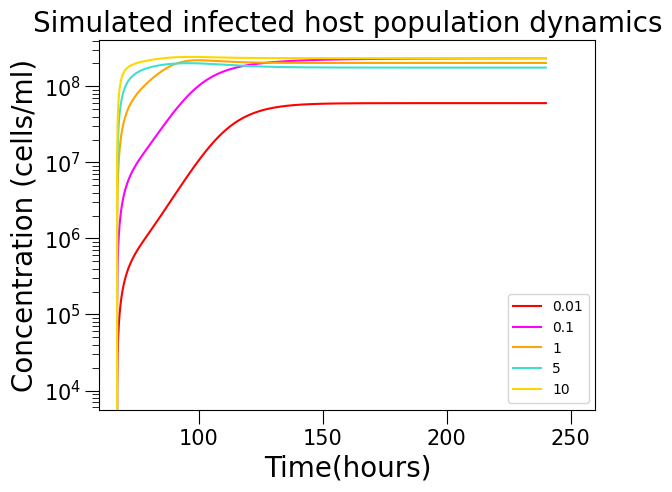

In [10]:

for i in (np.arange(5)+1):
    plt.semilogy(t,np.array(Pf_finals[i]).flatten()+np.array(Pe_finals[i]).flatten(), color = colors[i], label = MOI_vals[i])
    plt.xticks(range(0,260,50))
    plt.xlim(60,260)
    plt.ylabel("Concentration (cells/ml)")
    plt.xlabel("Time(hours)")
    plt.title("Simulated infected host population dynamics", fontsize = 20)
    plt.legend()
    #plt.savefig('Infected.png', bbox_inches = "tight")
plt.show()

### Distribution of superinfected pseudolysogens (Fig S2b)

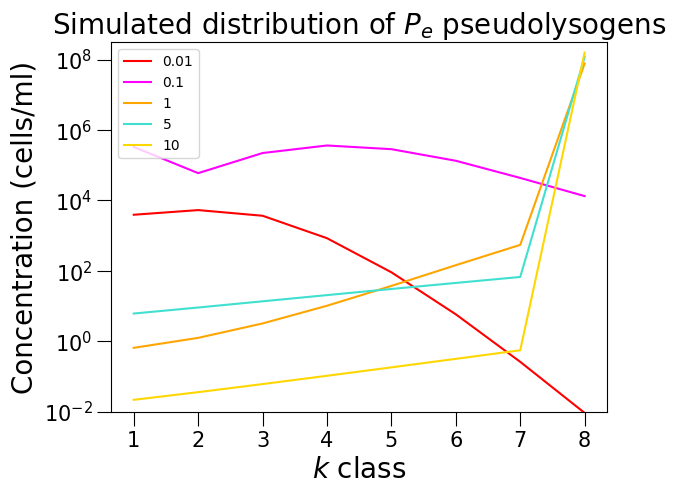

In [16]:
for i in (np.arange(5)+1):
    plt.semilogy(np.arange(1,len(Pe_dist_final[i])+1), Pe_dist_final[i], label = MOI_vals[i], color = colors[i])
    plt.xticks(range(1,9,1))
    plt.ylim(10**-2,10**8.5)
  
    plt.title(r'Simulated distribution of $P_e$ pseudolysogens', fontsize = 20)
    plt.ylabel('Concentration (cells/ml)')
    plt.xlabel(r'$k$ class')
    plt.legend()

#plt.savefig('P_dist_fin.pdf', bbox_inches = "tight")


## Viral Replication Model (Fig S15) 
### Need to change pars['z'] manually to change episomal viral replication rate ("Please refer to Modeling SI "Episomal Viral Replication" for details)

In [12]:
def Model_Replication(y,t,pars):
    if pars['n'] == 0:
        return ('Need n>0 classes')
    if pars['n'] == 1:
        dy= np.zeros(5)
        R = y[0]
        S = y[1]
        E = y[2]
        I = y[3]
        V = y[4]
        
        psy_R = pars['mu_max'] * (R/(R+pars['R_in']))
        gamma = (R/(R+pars['sig']*pars['R_in']))/(pars['R0']/(pars['R0']+pars['sig']*pars['R_in']))
        #gamma =1
        
        dy[0] =  - pars['e']* psy_R*(S+E) #R
        dy[1] = psy_R * S  - pars['phi'][0] * S* V +psy_R*E + psy_R*I #S
        dy[2] = pars['phi'][0] * S* V  - pars['lam'][0]*E  #E
        dy[3] = pars['lam'][0]*E - gamma*(pars['eta'] * I) #I
        dy[4] = gamma*(pars['bet']*pars['eta'] * I) - (pars['phi'][0]*S + pars['phi'][0]*E)* V #V
        
        return dy  
    else:
        dy = np.zeros(2*pars['n']+3)
        R = y[0]
        S = y[1]
        Pe_1 = y[2]
        Pe_s = y[3:(pars['n']+1)]
        Pe_k = y[pars['n'] + 1]
        Pf_1 = y[pars['n']+2]
        Pf_s = y[(pars['n']+3):(2*pars['n']+1)]
        Pf_k = y[2*pars['n'] + 1]
        V = y[2*pars['n'] + 2]

        Pe_prev = np.concatenate((Pe_1 ,  Pe_s[0:-1]), axis = None)
        Pe_total = np.concatenate((Pe_1 ,  Pe_s, Pe_k), axis = None)
        
        Pe_sum = np.sum(Pe_total)
        
        Pf_prev = np.concatenate((Pf_1 ,  Pf_s[0:-1]), axis = None)
        Pf_total = np.concatenate((Pf_1 ,  Pf_s, Pf_k), axis = None)
        
        Pf_sum = np.sum(Pf_total)

 
        psy_R = pars['mu_max'] * (R/(R+pars['R_in']))
        gamma = (R/(R+pars['sig']*pars['R_in']))/(pars['R0']/(pars['R0']+pars['sig']*pars['R_in']))

        Pe_topmid = np.concatenate((Pe_1 ,  Pe_s), axis = None)
        Pf_topmid = np.concatenate((Pf_1 ,  Pf_s), axis = None)
  
        
        
        lam_sum = np.sum(pars['lam'])


        dy[0] =  - pars['e']* psy_R*(S +(1/(1-pars['alpha'])) * ((np.sum(Pe_total))+np.sum(Pf_total))) - pars['dR'] * R #R
        #print(pars['rep'][1:-1])
        #print(Pe_total)
     
        dy[1] = psy_R * S  - pars['phi'][0]  * S* V   + 2*pars['z']* psy_R * np.sum(1/(1-pars['alpha']) * (pars['rep'][0]*Pe_total)) + 2* pars['z'] * psy_R * np.sum(1/(1-pars['alpha']) * (pars['rep'][0]*Pf_total)) - pars['dS']*S # S

        dy[2] = pars['phi'][0] * S * V - pars['phi'][1] * Pe_1 * V  -  (pars['lam'][0] * Pe_1) - (psy_R)*Pe_1 + 1/(1-pars['alpha'])* 2*psy_R *( pars['z'] * np.sum(pars['rep'][0]*(Pe_total), axis = 0) + (1- pars['z']) * Pe_1)-  pars['dE'] * Pe_1  #Pe_1

        dy[3:(pars['n']+1)]  = pars['phi'][1:-2] * Pe_prev * V - pars['phi'][2:-1] * Pe_s * V -  (pars['lam'][1:-1] * Pe_s) -(psy_R)*Pe_s + 2*psy_R *( pars['z'] * np.sum(pars['rep'][1:-1]*Pe_total, axis = 1)/(1-pars['alpha']) + (1- pars['z']) * Pe_s)- pars['dE'] * Pe_s  # Pe_s
        
        dy[pars['n']+1]  = pars['phi'][-1] * Pe_topmid[-1]*V -  (pars['lam'][-1] * Pe_k) -  (psy_R)*Pe_k +  2*psy_R*(pars['z'] * np.sum(pars['rep'][-1]*(Pe_k), axis = 0)/(1-pars['alpha']) +  (1- pars['z']) * Pe_k )-  pars['dE'] * Pe_k  #Pe_K

        dy[pars['n']+2] = pars['lam'][0]*Pe_1 - gamma * (pars['eta'] * (Pf_1)) -  (psy_R)*Pf_1 + 1/(1-pars['alpha'])* 2*psy_R*(pars['z'] * np.sum(pars['rep'][0]*(Pf_total), axis = 0) + (1- pars['z']) * Pf_1) #Pf_1
        
        dy[(pars['n']+3):(2*pars['n']+1)] = (pars['lam'][1:-1] * Pe_s) - gamma * (pars['eta'] * (Pf_s)) - (psy_R)*Pf_s + 2*psy_R * ( pars['z'] * np.sum(pars['rep'][1:-1]*Pf_total, axis = 1)/(1-pars['alpha']) + (1- pars['z']) * Pf_s) #Pf_s
        
        dy[2*pars['n'] + 1]= pars['lam'][-1]*Pe_k - gamma * (pars['eta'] * (Pf_k)) -  (psy_R)*Pf_k +  2*psy_R* (pars['z']*np.sum(pars['rep'][-1]*(Pf_k), axis = 0)/(1-pars['alpha']) + (1- pars['z']) * Pf_k)#Pf_k
        
        dy[2*pars['n']+2] = pars['bet']*gamma * (pars['eta'] * (Pf_sum))- V*(pars['phi'][0] * S + np.sum(pars['phi'][2:-1] * Pe_prev) + pars['phi'][-1] * Pe_topmid[-1]) - pars['dV'] * V #V
        
 
        
        #print(np.sum(pars['bet']*I*pars['eta']))
        #print(psy_R)
        return dy  

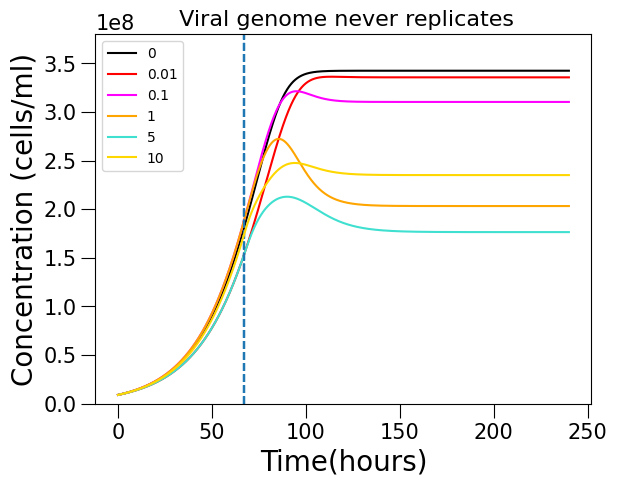

In [13]:
mu_max_vals=[0.061,0.058,0.063,0.063,0.058,0.062]

MOI_vals= [10,5,1,0.1,0.01,0]
colors = ['black','red','fuchsia','orange','turquoise','gold']
mu_max_vals.reverse()
MOI_vals.reverse()
virus_insert_time = 67
Rvals = []
Svals = []

Pf_finals = []
Pe_finals = []

pars['z'] =1 #change to modify replication rate of viral episome 
pars['sig']= 0.06

Pe_dist_final=[]
for b in range(len(mu_max_vals)):
    pars['mu_max'] = mu_max_vals[b]
    t0 = 0
    tf = virus_insert_time
    tstep = 0.1
    t = np.arange(t0,tf+tstep,tstep)

    y01 = np.zeros(2*pars['n']+3)
    y01[0] = pars['R0'] #initial resource concentration 
    y01[1] = S0  #initial susceptible concentration 
    y01[-1] = 0#initial free virus concentration 
    y1 = integrate.odeint(Model_Replication,y01,t,atol = 10**-8,args=(pars,))
    R_0 = y1[:,0]
    S_0 = y1[:,1]
    Pe1_0 = y1[:,2]
    Pe_mid_0 = y1[:,3:(pars['n']+1)]
    Pe_final_0 = y1[:,(pars['n']+1)]
    Pf1_0 = y1[:,pars['n']+2]
    Pf_mid_0 = y1[:,(pars['n']+3):(2*pars['n']+1)]
    Pf_final_0 = y1[:,2*pars['n'] + 1]
    V=y1[:,(2*pars['n']+2)]

    Pe_total_mid_0 = np.sum(Pe_mid_0, axis = 1)
    Pf_total_mid_0 = np.sum(Pf_mid_0, axis = 1)
    Pe_total_0 = np.sum([Pe1_0,Pe_total_mid_0,Pe_final_0], axis = 0)

    Pf_total_0 = np.sum([Pf1_0,Pf_total_mid_0,Pf_final_0], axis = 0)

    host_pop_0 = S_0 + Pe_total_0 + Pf_total_0
    plt.ylabel('Concentration (cells/ml)')
    plt.xlabel('Time(hours)')

    plt.title('S+Pe+Pf+L')
    plt.axvline(virus_insert_time, linestyle = '--')
    plt.plot(t,host_pop_0, color = colors[b])
    Rvals.append(R_0[-1])
    Svals.append(S_0[-1])

    #######
    
    t0 = virus_insert_time
    tf = 240
    tstep = 0.1
    t = np.arange(t0,tf+tstep,tstep)

    y01 = np.zeros(2*pars['n']+3)
    BULK_MOI  = MOI_vals[b]
    y01[0] = Rvals[b] #initial resource concentration 
    y01[1] = Svals[b] #initial susceptible concentration 
    y01[-1] = BULK_MOI * y01[1] #initial free virus concentration 
    #print( y01[1])
    #print(MOI_vals[i])
    y1 = integrate.odeint(Model_Replication,y01,t,atol = 10**-8,args=(pars,))
    
    R3= y1[:,0]
    S3 = y1[:,1]
    Pe13 = y1[:,2]
    Pe_mid3 = y1[:,3:(pars['n']+1)]
    Pe_final3 = y1[:,(pars['n']+1)]
    Pf13 = y1[:,pars['n']+2]
    Pf_mid3 = y1[:,(pars['n']+3):(2*pars['n']+1)]
    Pf_final3 = y1[:,2*pars['n'] + 1]
    V3=y1[:,(2*pars['n']+2)]

    Pe_total_mid3 = np.sum(Pe_mid3, axis = 1)
    Pf_total_mid3 = np.sum(Pf_mid3, axis = 1)
    Pe_total3 = np.sum([Pe13,Pe_total_mid3,Pe_final3], axis = 0)

    Pf_total3 = np.sum([Pf13,Pf_total_mid3,Pf_final3], axis = 0)

    host_pop3 = S3 + Pe_total3 + Pf_total3
    
    plt.plot(t,host_pop3, color = colors[b], label = str(BULK_MOI))
    plt.ylabel('Concentration (cells/ml)')
    plt.xlabel('Time(hours)')
    if pars['z'] == 1:
        gens = ' Viral genome never replicates'
    elif pars['z'] == 0:
        gens = ' Viral genome replicates every generation'
    else:
        gens =  'Viral genome replicates every '  + str(round(1/(1-pars['z']),2)) + ' generations'
    plt.title(gens , fontsize = 16)
    Pe_dist=[]
    Pe_dist.append(Pe13[-1])
    for a in range(len(Pe_mid3[0])):
        Pe_dist.append(Pe_mid3[:,a][-1])
    Pe_dist.append(Pe_final3[-1])
    Pe_dist_final.append(Pe_dist) 
    plt.legend()
    
    Pf_finals.append(Pf_total3)
    Pe_finals.append(Pe_total3)
plt.ylim(0,3.8*10**8)
#plt.savefig('Replication.svg', bbox_inches = "tight")
plt.show()



